# 实验一 最近邻分类器

将下面的代码补充完整，实现使用最近邻分类器功能

## 读取MNIST数据集，并将其划分为train/val/test数据集

### MNIST数据集读取

In [2]:
import gzip
import os
import struct
import numpy as np

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels), 784)

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):
    
    total_len = images.shape[0]
    offset = int(total_len * ratio)
    
    val_img = images[:offset][:]
    val_lb = labels[:offset]
    
    train_img = images[offset:][:]
    train_lb = labels[offset:]
    
    return train_img, train_lb, val_img, val_lb    

### 按照 5:1:1 划分为训练集，验证集，测试集


In [3]:
# 读取训练集和测试集数据
[images, labels] = load_mnist('../MNIST', kind='train')
[test_img, test_lb] = load_mnist('../MNIST',kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)


# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape)

训练集图像格式为: (50000, 784) 训练集标签格式为: (50000,)
验证集图像格式为: (10000, 784) 验证集标签格式为: (10000,)
测试集图像格式为: (10000, 784) 测试集标签格式为: (10000,)


## 最近邻分类器

### 定义 Nearest Neighbor Classifier

此段添加了L2距离的代码

In [3]:
import numpy as np

class NearestNeighbor(object):
    def __init__(self):
        pass
    
    # 读入图像和标签数据并保存
    def train(self, X, y):
        # X is N x D and Y is 1-dimension of size N
        self.Xtrain = X
        self.ytrain = y
    
    # 按照最近邻原则分类
    def predict(self, X):
        # X is N x D where each row is an example we wish to predict label for
        num_test = X.shape[0]
        Ypred = np.zeros((num_test, 1), dtype=self.ytrain.dtype)
        
        for i in range(num_test):
            # L1 Distance
            # distances1 = np.sum(np.abs(self.Xtrain - X[i][:]), axis=1)
            # min_index = np.argmin(distances1) # get the index with smallest distance

            # L2 Distance
            distances2 = np.sum(np.square(self.Xtrain - X[i][:]), axis=1)
            min_index = np.argmin(distances2)
            Ypred[i] = self.ytrain[min_index] # predict the label of the nearest example

        return Ypred

### 测试 Nearest Neighbor Classifier

In [4]:
# 实例化Nearest Neighbor Classifier
nn = NearestNeighbor()
nn.train(train_img[0:1000,:], train_lb[0:1000])
Yval_predict = nn.predict(val_img[0:1000,:])

# 在验证集上测试精确度
validation_accuracy = np.mean(Yval_predict == val_lb[0:1000])
print ('accuracy: %f' % (validation_accuracy ,))

accuracy: 0.111358


实验要求：   
1、将最近邻分类器的距离度量方法修改为”L2距离“，给出分类精度；   
2、分析K取不同值对分类结果的影响，把精度随k值的变化曲线，使用matplotlib库画出    
3、使用MNIST数据，建立一个线性分类器，使用随机搜索算法，更新参数，分析实验结果。

## K近邻分类器

### 定义 KNearest Neighbor Classifier

In [5]:
import numpy as np

class KNearestNeighbor(object):
    def __init__(self):
        pass

    def train(self, X, y):
        self.Xtrain = X
        self.ytrain = y

    def predict(self, X, k):
        num_test = X.shape[0]
        Ypred = np.zeros((num_test, 1), dtype=self.ytrain.dtype)

        for i in range(num_test):
            # L2 Distance
            distances2 = np.sum(np.square(self.Xtrain - X[i][:]), axis=1)
            min_index = np.argsort(distances2)[:k]
            knn_labels = self.ytrain[min_index]
            Ypred[i] = np.bincount(knn_labels).argmax()

        return Ypred

### 测试 KNearest Neighbor Classifier

In [6]:
# 实例化KNN并测试不同k值
accuracies = []
for k in range(1,20):
    knn = KNearestNeighbor()
    knn.train(train_img[0:1000,:], train_lb[0:1000])
    Yval_predict = knn.predict(val_img[0:1000,:], k)

    # 在验证集上测试精确度
    knn_validation_accuracy = np.mean(Yval_predict == val_lb[0:1000])
    accuracies.append(knn_validation_accuracy)
    print ('k: %d, accuracy: %f' % (k, knn_validation_accuracy))

k: 1, accuracy: 0.111358
k: 2, accuracy: 0.112416
k: 3, accuracy: 0.113025
k: 4, accuracy: 0.113345
k: 5, accuracy: 0.113494
k: 6, accuracy: 0.113938
k: 7, accuracy: 0.114158
k: 8, accuracy: 0.114320
k: 9, accuracy: 0.114561
k: 10, accuracy: 0.114723
k: 11, accuracy: 0.114949
k: 12, accuracy: 0.115051
k: 13, accuracy: 0.115134
k: 14, accuracy: 0.115063
k: 15, accuracy: 0.115118
k: 16, accuracy: 0.115179
k: 17, accuracy: 0.115290
k: 18, accuracy: 0.115385
k: 19, accuracy: 0.115483


### 绘制精度随k值变化的曲线

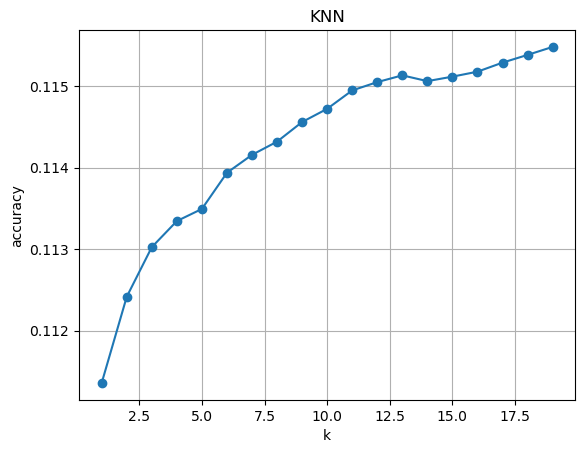

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(1,20), accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('KNN')
plt.grid(True)
plt.show()

## 线性分类器

### 定义 Linear Classifier

In [8]:
# 线性分类器
class LinearClassifier(object):
    def __init__ (self):
        pass

    def train(self, X, y, X_val, y_val, it=10000, m=0.01):
        X = X / 255.0
        self.W = np.random.randn(X.shape[1], y.max()+1) * 0.01
        self.b = np.zeros(y.max()+1) * 0.01

        loss = self.cross_entropy_loss(X, y, self.W, self.b)
        best_loss = loss
        self.loss_history = []
        self.loss_history.append(best_loss)

        self.acc_history = [] 
        self.acc_history.append(np.mean(self.predict(X_val) == y_val))

        for i in range(it):
            W_new = self.W + np.random.randn(X.shape[1], y.max()+1) * m
            b_new = self.b + np.random.randn(y.max()+1) * m
            loss = self.cross_entropy_loss(X, y, W_new, b_new)

            if loss < best_loss:
                best_loss = loss
                self.W = W_new
                self.b = b_new
                # print('Iteration %d: loss %f' % (i, loss))

            self.loss_history.append(best_loss)
            acc = np.mean(self.predict(X_val) == y_val)
            self.acc_history.append(acc)
            # print ('i: %d, accuracy: %f' % (i, acc))

    def cross_entropy_loss(self, X, y, w, b):
        scores = np.dot(X, w) + b
        scores = np.clip(scores, -100, 100) 
        scores -= np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        probs = exp_scores / (np.sum(exp_scores, axis=1, keepdims=True) + 1e-8)
        probs = np.clip(probs, 1e-8, 1.0)
        loss = -np.sum(np.log(probs[np.arange(X.shape[0]), y])) / X.shape[0]
        return loss
    
    def predict(self, X):
        X = X / 255.0
        scores = np.dot(X, self.W) + self.b
        scores = np.clip(scores, -100, 100)
        scores -= np.max(scores, axis=1, keepdims=True)
        scores = np.exp(scores)
        scores /= np.sum(scores, axis=1, keepdims=True)
        return np.argmax(scores, axis=1)

### 测试 Linear Classifier

In [9]:
# 实例化线性分类器
lc = LinearClassifier()
lc.train(train_img[0:1000,:], train_lb[0:1000], val_img[0:1000,:], val_lb[0:1000])
Yval_predict = lc.predict(val_img[0:1000,:])

# 在验证集上测试精确度
validation_accuracy = np.mean(Yval_predict == val_lb[0:1000])
print ('accuracy: %f' % (validation_accuracy))

accuracy: 0.833000


### 绘制损失和精确度随迭代次数变化曲线

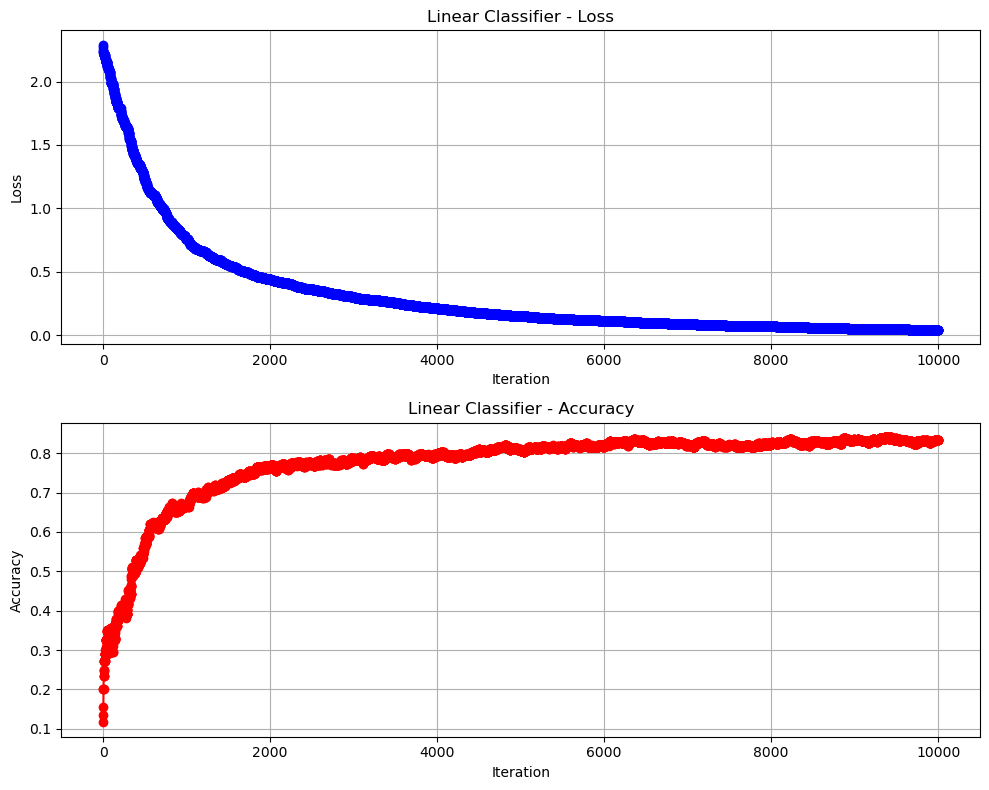

In [10]:
# 绘制变化曲线
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(range(1, len(lc.loss_history) + 1), lc.loss_history, marker='o', color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Linear Classifier - Loss')
ax1.grid(True)

ax2.plot(range(1, len(lc.acc_history) + 1), lc.acc_history, marker='o', color='red')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Accuracy')
ax2.set_title('Linear Classifier - Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()